In [3]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../../QHamSolver/Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)


import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{physics}\usepackage{xcolor}\usepackage{amsmath}\usepackage{amsfonts}'


%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


def base_dir(BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/" + (f"PBC/" if BC else f"OBC/")
    return dirx

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/LGT_Project/2DFermiHubbard/Jupyter_Notebook
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../../QHamSolver/Python/


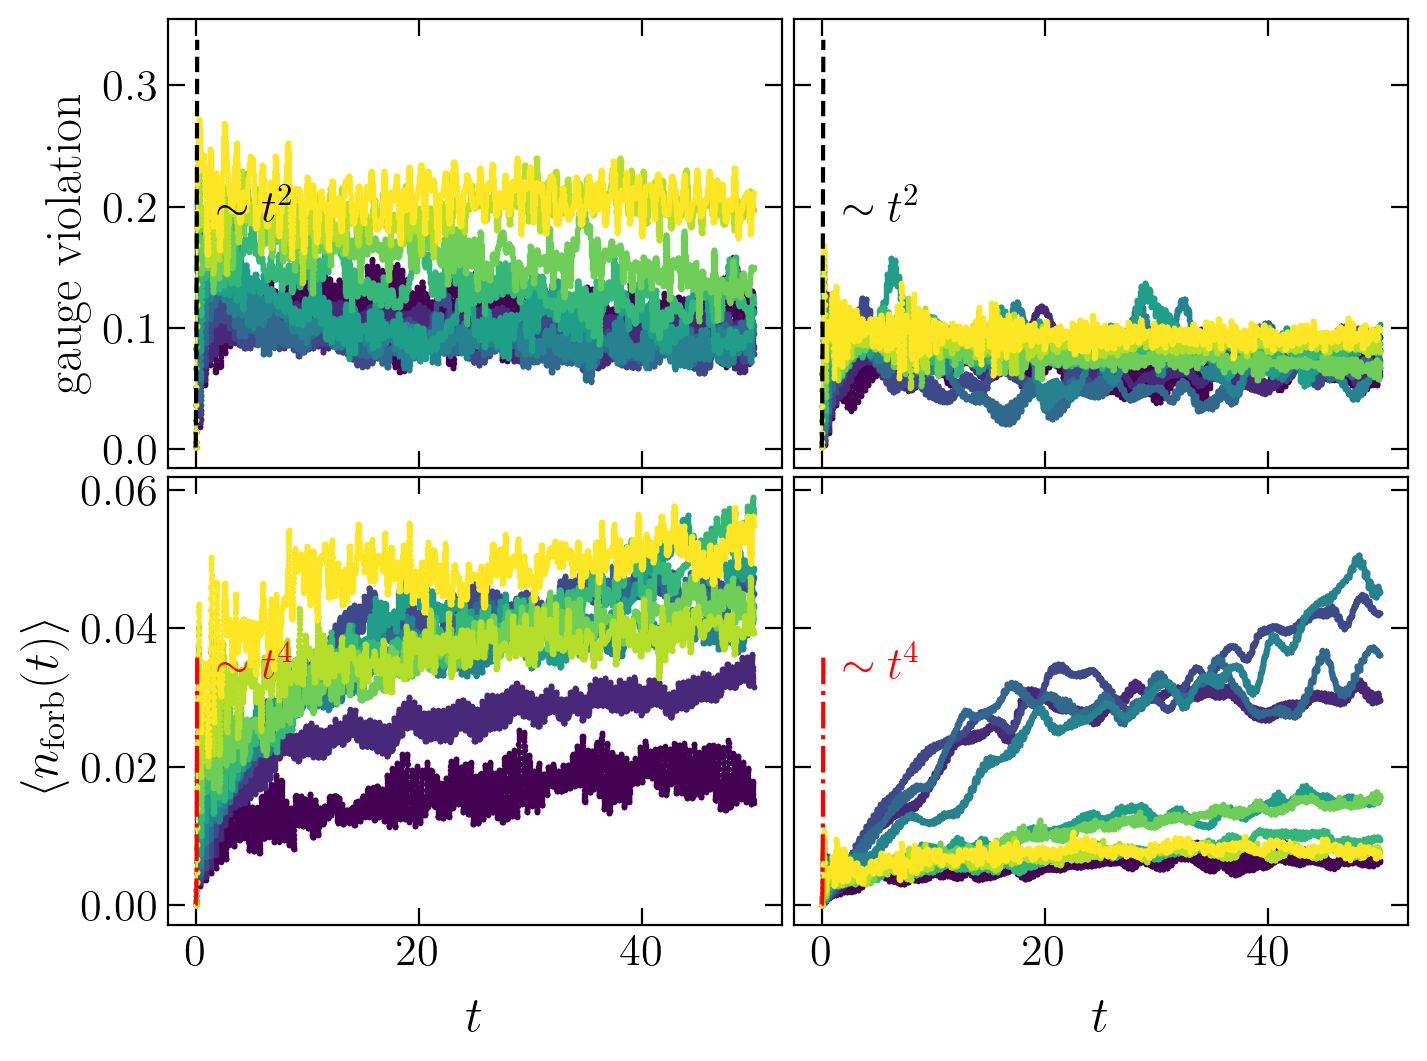

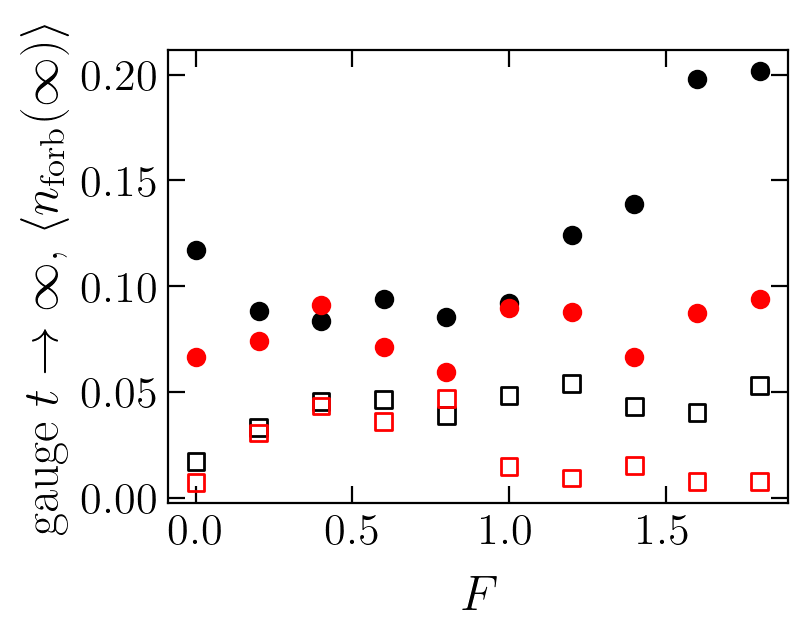

In [59]:
Lx = 4
Ly = 4
Nu = 2
Nd = 2
J = 1
U = 24
delta = 12
BC = 1 #PBC: BC=1

Flist = np.arange(0.0, 2, 0.2)
norm = matplotlib.colors.Normalize(
                vmin=min(Flist),
                vmax=max(Flist) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8,6), dpi = 200, sharex=True, sharey='row')
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey='row')

for iiU, U in enumerate( [24, 36] ):
    delta = U/2
    gauge = np.zeros(Flist.shape)
    density = np.zeros(Flist.shape)
    for iiF, Fx in enumerate(Flist):
        col = s_m.to_rgba(Fx)
        
        name = base_dir(BC) + "GaugeViolation/" + info(Lx, Ly, Nu, Nd, J, U, delta, Fx)
        if exists(name):
            with h5py.File(name, "r") as file:
                try:
                    times = np.array(file.get('times'))[0][1:]
                    gauge_violation = np.array(file.get('gauge_violation'))[0][1:]
                    density_forbidden = np.array(file.get('density_forbidden'))[0][1:]
                    
                    axis[0, iiU].plot(times, gauge_violation, color = col, marker='o', markersize=1, lw=0.7)
                    axis[1, iiU].plot(times, density_forbidden, color = col, marker='o', markersize=1, lw=0.7)
                    
                    gauge[iiF] = np.mean(gauge_violation[-200:])
                    density[iiF] = np.mean(density_forbidden[-200:])
                except IndexError:
                    print(name)
        else:
            print(name)

    axis2.scatter(Flist, gauge, marker='o', color='red' if iiU else 'k', label = r"gauge $t\to\infty$")
    axis2.scatter(Flist, density, marker='s', color='red' if iiU else 'k', facecolor='None', label = r"$\langle n_{\rm forbidden}(\infty)\rangle$")

    scale = 'linear'
    fig_help.set_plot_elements(axis[0, iiU], ylabel=r"gauge violation" if iiU==0 else "", xlabel=r"", font_size=16, set_legend=0, xscale=scale, yscale=scale)
    fig_help.set_plot_elements(axis[1, iiU], ylabel=r"$\langle n_{\rm forb}(t)\rangle$" if iiU==0 else "", xlabel=r"$t$", font_size=16, set_legend=0, xscale=scale, yscale=scale)

    x = np.linspace(min(times), 0.15, 1000)
    axis[0, iiU].plot(x, 15*x**2, color = 'k', ls='--')
    axis[1, iiU].plot(x, 72*x**4, color = 'red', ls='-.')
    axis[0, iiU].annotate(r"$\sim t^2$", fontsize=16, xy=(0.08, 0.55), xycoords='axes fraction', color='k')
    axis[1, iiU].annotate(r"$\sim t^4$", fontsize=16, xy=(0.08, 0.55), xycoords='axes fraction', color='red')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

fig_help.set_plot_elements(axis2, ylabel=r"gauge $t\to\infty$, $\langle n_{\rm forb}(\infty)\rangle$", xlabel=r"$F$", font_size=16, set_legend=0, xscale='linear', yscale='linear')       